In [1]:
header = "D:/K_sunada/result/CDY154/"

## 1/17 fogi calibration - DPR1-L-120-44

In [2]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [3]:
import sklearn
from sklearn.decomposition import PCA

## ac stark shift

In [4]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [5]:
def double_Lorentzian(freq, amp1, const, center1, k1, amp2, center2, k2):
    return const - amp1*k1**2/((freq-center1)**2 + k2**2)- amp2*k2**2/((freq-center2)**2 + k2**2)

In [6]:
ac = "/2024-01-17/2024-01-17T110647_11d49cb4-42_fogi_ac_Stark_shift"
dd_ac = datadict_from_hdf5(header + ac +"/data")

xs = []
ys = []

for i in range(14):
    ini = 81*i
    fin = 81*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

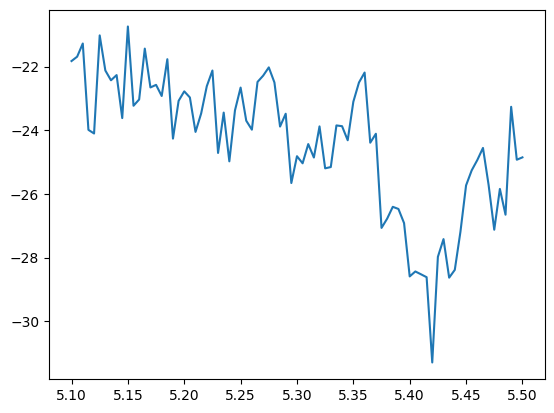

In [7]:
plt.plot(xs[0], ys[0])
plt.show()

In [8]:
par_ini = {
    'amp': 8,
    'const':-20,
    'center':5.4,
    'k':0.085
}
par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}
par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}
par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [9]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [10]:
results = []
for i in range(14):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

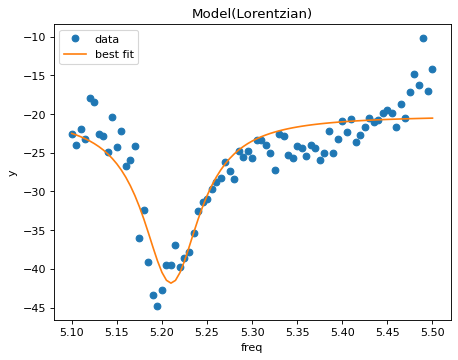

In [11]:
fig, ax = plt.subplots(dpi=80)
id = 13
results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
plt.show()
results[id]

In [12]:
peak_y = [5.41962589, 5.41342571, 5.41107526, 5.40451109, 5.39528829, 5.3844023,
          5.36637479, 5.34954768, 5.32605246, 5.30367389, 5.27703794, 5.25393195,
          5.23079752, 5.21005015]

In [32]:
xs = []
ys = []
zs = []

for i in range(14):
    ini = 81*i
    fin = 81*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['amplitude']['values'][ini:fin]
    z = np.angle(dd_ac['s11']['values'][ini:fin])
    xs.append(x)
    ys.append(y)
    zs.append(z)

In [33]:
x = dd_ac['fogi_freq']['values']
y = dd_ac['amplitude']['values']
z = np.angle(dd_ac['s11']['values'])

C:\Users\qipe\AppData\Local\Temp\ipykernel_12624\3046514742.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


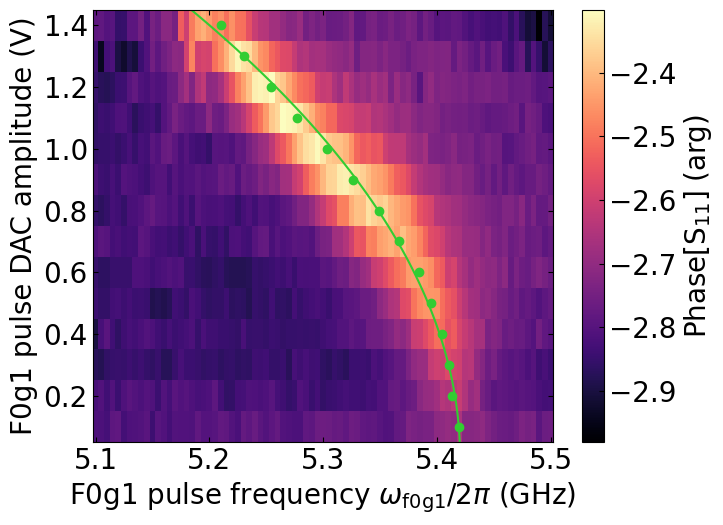

In [40]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_ylabel("F0g1 pulse DAC amplitude (V)")
ax.set_xlabel("F0g1 pulse frequency $\omega_\mathrm{f0g1}/2\pi$ (GHz)")
# ax.set_xlim(-10, 20)
# ax.set_ylim(10, 10.6)

maingraph = ax.pcolormesh(xs,ys, zs, vmin=min(np.unique(z)), vmax=max(np.unique(z)), cmap=cm, shading='auto')
plt.colorbar(maingraph, label="Phase[S$_{11}$] (arg)")
plt.tick_params(top='on',bottom='on',left='on',right='on')

peak_x =np.array([0.1, 0.2,0.3,  0.4,0.5,  0.6 ,0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4])
x = np.linspace(0.05, 1.45, 100)
plt.plot(peak_y, peak_x,'o' ,color ='limegreen')
plt.plot(5.42038551-0.11227609*x**2, x,'-' ,color ='limegreen')
# plt.savefig('fogi_ac_Stark.png', bbox_inches='tight')
plt.show()

In [16]:
import sklearn
from sklearn.decomposition import PCA

In [17]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [18]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

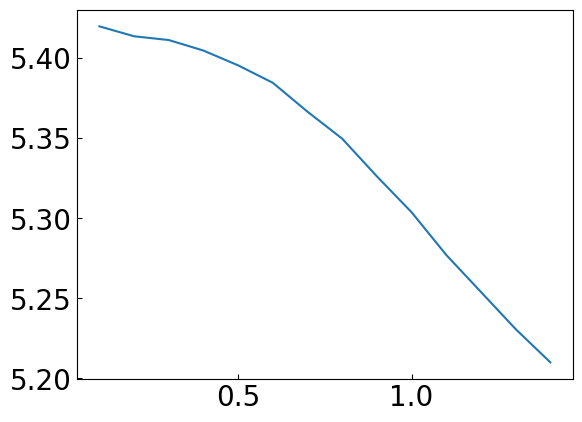

In [19]:
peak_x =[0.1, 0.2,0.3,  0.4,0.5,  0.6 ,0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
plt.plot(peak_x, peak_y)

In [20]:
def ac_stark(amp, const, alpha):
    return const - alpha*(amp**2)

In [21]:
par_ini = {
    'const':5.45,
    'alpha':0.14
}
par_min = {
    'const':0,
    'alpha':-np.inf
}
par_max = {
    'const':np.inf,
    'alpha':np.inf
}
par_vary = {
    'const':True,
    'alpha':True
}

In [22]:
model = lmfit.Model(ac_stark)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [23]:
result = model.fit(data = peak_y, params=params, amp = peak_x)
result

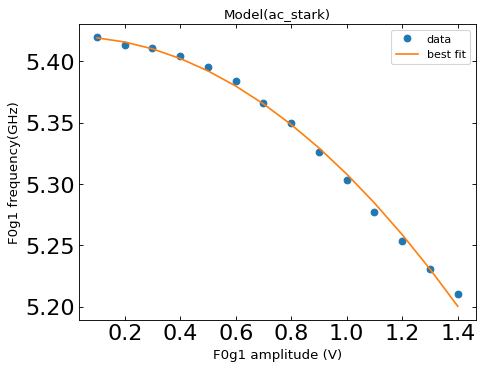

In [24]:
fig, ax = plt.subplots(dpi=80)

plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
# plt.plot(x ,result.init_fit)

plt.xlabel("F0g1 amplitude (V)", size = "large")
plt.ylabel("F0g1 frequency(GHz)", size = "large")



plt.show()

In [25]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

fogi duration

In [42]:
pi_fogi = "/2024-01-17/2024-01-17T114518_73864e43-41_fogi_duration_sweep"
dd = datadict_from_hdf5(header + pi_fogi +"/data")

x = np.unique(dd['fogi_duration']['values'])
ys = []
y_r = np.real(dd['s11']['values'][0:51])
y_i = np.imag(dd['s11']['values'][0:51])
for i in range(6):
    ini = i*51
    y_real = np.real(dd['s11']['values'][ini:ini+51])
    y_imag = np.imag(dd['s11']['values'][ini:ini+51])
    y = PCA_transform1(y_r, y_i, y_real, y_imag)[2]
    ys.append(y)


In [43]:
len(ys[0]), len(x)

(51, 51)

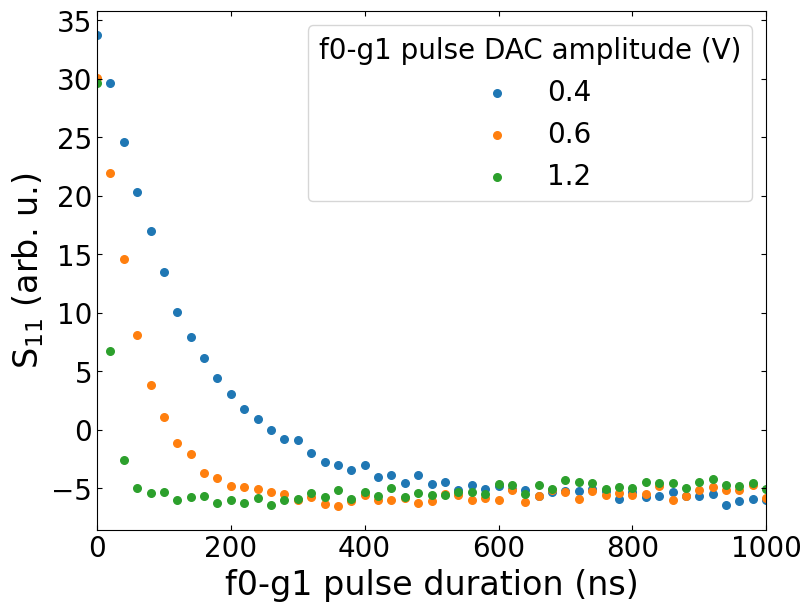

In [45]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.scatter(x, ys[0], s= 30 , label = "0.4") #0.4
plt.scatter(x, ys[1], s= 30 , label = "0.6") #0.6
plt.scatter(x, ys[4], s= 30 , label = "1.2" ) #0.8
plt.title("")
legend = plt.legend()
legend.set_title("f0-g1 pulse DAC amplitude (V)")
ax.set_xlabel('f0-g1 pulse duration (ns)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
ax.set_xlim(0, 1000)
# plt.savefig('fogi_duration.png', bbox_inches='tight')
plt.show()

In [29]:
kappa_e  = 250 *2*np.pi
delta_g = (10.3-5.6)*2*np.pi
delta_f =(2*8-0.3-2*5.6)*2*np.pi
Delta_d = delta_f-delta_g

g = (0.002*(10.3-5.6))**0.5*2*np.pi
Omega = 1
Delta = 8-10.3
alpha = -0.3
g_eff = (g*alpha*Omega/(2**0.5*Delta*(Delta+alpha)))**2

X = kappa_e**2/16 - Delta_d**2/4 - g_eff**2
Y = -kappa_e*Delta_d/4
X, Y

(154212.17398262708, 493.48022005447064)

In [30]:
cos = X/(X**2+Y**2)**0.5
cos2 = ((cos+1)/2)**0.5
Re1 = -kappa_e/4 + (X**2+Y**2)**0.25*cos2
Re2 = -kappa_e/4 - (X**2+Y**2)**0.25*cos2
Re1, Re2, cos2

(-2.7768010113504715e-10, -785.3981633971705, 0.9999987200024576)